In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import pytorch_lightning as pl

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("../data/processed/daily_sales.csv")

df.head()

,Date,Sales
0,2009-12-01,44048.69
1,2009-12-02,52941.99
2,2009-12-03,67479.08
3,2009-12-04,34064.41
4,2009-12-05,9803.05


In [3]:
sales = df["Sales"].values.reshape(-1,1)

scaler = MinMaxScaler()

sales_scaled = scaler.fit_transform(sales)

sales_scaled[:5]

array([[0.22437423],
       [0.27353288],
       [0.35388818],
       [0.16918507],
       [0.03507785]])

In [4]:
sequence_length = 30

X = []
y = []

for i in range(len(sales_scaled) - sequence_length):
    X.append(sales_scaled[i:i+sequence_length])
    y.append(sales_scaled[i+sequence_length])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(574, 30, 1)
(574, 1)


In [5]:
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(459, 30, 1)
(115, 30, 1)


In [6]:
class SalesDataset(Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [7]:
train_dataset = SalesDataset(X_train, y_train)
test_dataset = SalesDataset(X_test, y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

len(train_loader), len(test_loader)

(15, 4)

In [8]:
class LSTMForecast(pl.LightningModule):

    def __init__(self):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=50,
            batch_first=True
        )

        self.fc = nn.Linear(50, 1)

        self.loss_fn = nn.MSELoss()

    def forward(self, x):

        out, (hidden, cell) = self.lstm(x)

        out = self.fc(hidden[-1])

        return out

    def training_step(self, batch, batch_idx):

        x, y = batch

        pred = self(x)

        loss = self.loss_fn(pred, y)

        self.log("train_loss", loss)

        return loss

    def configure_optimizers(self):

        return torch.optim.Adam(
            self.parameters(),
            lr=0.001
        )

In [9]:
model = LSTMForecast()

model

LSTMForecast(
  (lstm): LSTM(1, 50, batch_first=True)
  (fc): Linear(in_features=50, out_features=1, bias=True)
  (loss_fn): MSELoss()
)

In [10]:
trainer = pl.Trainer(
    max_epochs=20,
    enable_checkpointing=False,
    logger=False
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [11]:
trainer.fit(
    model,
    train_loader
)

┏━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ lstm    │ LSTM    │ 10.6 K │ train │     0 │
│ 1 │ fc      │ Linear  │     51 │ train │     0 │
│ 2 │ loss_fn │ MSELoss │      0 │ train │     0 │
└───┴─────────┴─────────┴────────┴───────┴───────┘

Trainable params: 10.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 10.7 K                                                                                               
Total estimated model params size (MB): 0.043                                                                      
Modules in train mode: 3                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\
Python312\site-packages\rich\live.py:256: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
`Trainer.fit` stopped: `max_epochs=20` reached.


In [12]:
model.eval()

with torch.no_grad():
    predictions = model(
        torch.tensor(
            X_test,
            dtype=torch.float32
        )
    )

predictions.shape

torch.Size([115, 1])

In [13]:
predictions = predictions.numpy()

predictions_actual = scaler.inverse_transform(
    predictions
)

y_actual = scaler.inverse_transform(
    y_test
)

predictions_actual[:5]

array([[23900.797],
       [28173.322],
       [26444.152],
       [27390.066],
       [26231.467]], dtype=float32)

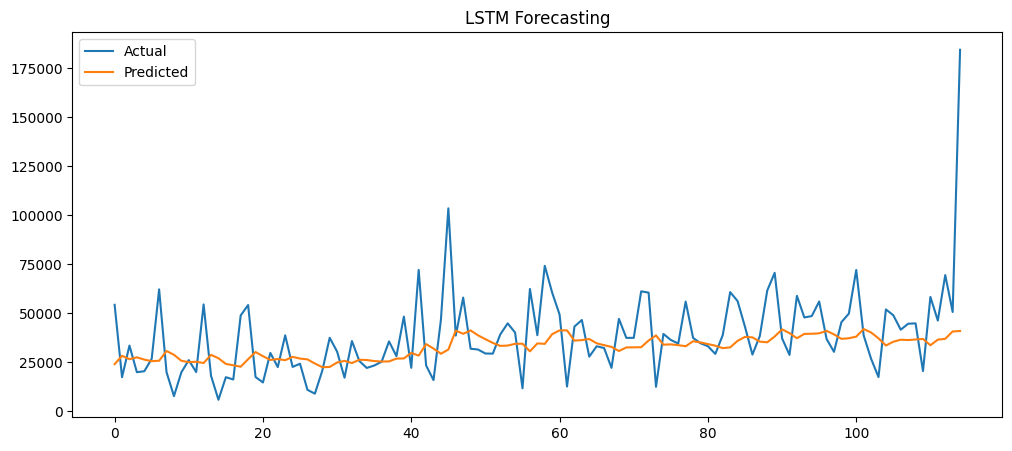

In [14]:
plt.figure(figsize=(12,5))

plt.plot(
    y_actual,
    label="Actual"
)

plt.plot(
    predictions_actual,
    label="Predicted"
)

plt.title("LSTM Forecasting")

plt.legend()

plt.show()

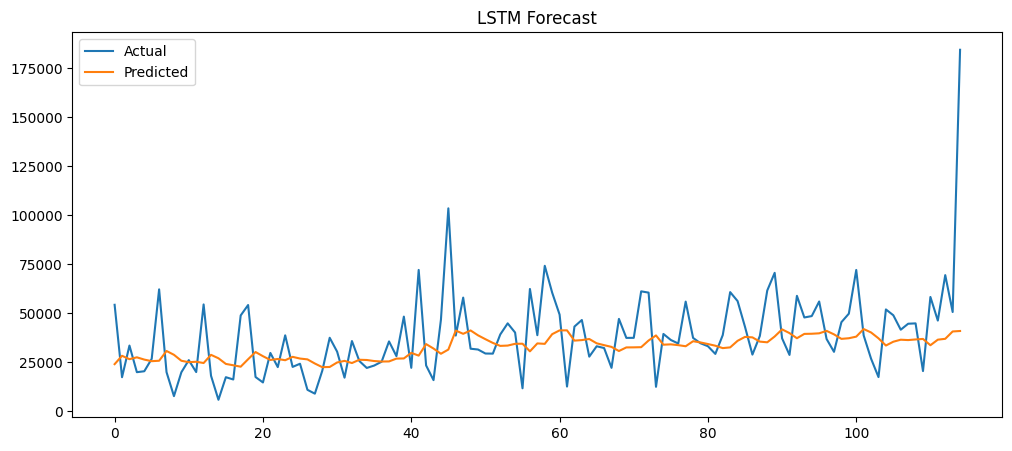

In [15]:
plt.figure(figsize=(12,5))

plt.plot(y_actual,label="Actual")
plt.plot(predictions_actual,label="Predicted")

plt.title("LSTM Forecast")
plt.legend()

plt.savefig(
    "../screenshots/lstm_forecast.png"
)

plt.show()

In [16]:
forecast_df = pd.DataFrame({
    "Actual": y_actual.flatten(),
    "Predicted": predictions_actual.flatten()
})

forecast_df.to_csv(
    "../data/processed/lstm_forecast.csv",
    index=False
)

print("LSTM forecast saved successfully!")

LSTM forecast saved successfully!
